# Simulación de Montecarlo — Avance Parcial
**Curso:** Computación de Alto Desempeño y Cloud Computing 2026-I
**Fuente del código:** elaboración propia

## 1. Carga del Dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import multiprocessing
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor  # <-- cambio aquí
import time

# Cargar dataset
df = pd.read_csv(r'X:\Carpetas Personales\Santiago W\contaminantes_lima.csv')
print(df.shape)
df.head()

(577794, 15)


,ID,ESTACION,FECHA,HORA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,FECHA_CORTE
0,1,CAMPO_DE_MARTE,20150101,50000,-77.0432,-12.0705,117.0,37.92,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
1,2,CAMPO_DE_MARTE,20150101,60000,-77.0432,-12.0705,117.0,153.39,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
2,3,CAMPO_DE_MARTE,20150101,70000,-77.0432,-12.0705,117.0,116.49,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
3,4,CAMPO_DE_MARTE,20150101,80000,-77.0432,-12.0705,117.0,80.74,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
4,5,CAMPO_DE_MARTE,20150101,90000,-77.0432,-12.0705,117.0,27.40,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531


## 2. Exploración Inicial

In [17]:
# Ver dimensiones (Filas, Columnas)
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

# Ver nombres de las columnas
print(f"Columnas presentes: {df.columns.tolist()}\n")

# Ver tipos de datos
print(f"Tipos de datos por columna: \n{df.dtypes}\n")

# Ver estadísticas descriptivas
print(f"Estadísticas descriptivas: {df.describe()}\n")

El dataset tiene 577794 filas y 15 columnas.

Columnas presentes: ['ID', 'ESTACION', 'FECHA', 'HORA', 'LONGITUD', 'LATITUD', 'ALTITUD', 'PM10', 'PM2_5', 'NO2', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'UBIGEO', 'FECHA_CORTE']

Tipos de datos por columna: 
ID                int64
ESTACION            str
FECHA             int64
HORA              int64
LONGITUD        float64
LATITUD         float64
ALTITUD         float64
PM10            float64
PM2_5           float64
NO2             float64
DEPARTAMENTO        str
PROVINCIA           str
DISTRITO            str
UBIGEO          float64
FECHA_CORTE       int64
dtype: object

Estadísticas descriptivas:                   ID         FECHA           HORA       LONGITUD  \
count  577794.000000  5.777940e+05  577794.000000  577794.000000   
mean   288897.500000  2.019287e+07  114991.640619     -77.008514   
std    166794.905056  2.723089e+04   69226.352729       0.049144   
min         1.000000  2.015010e+07       0.000000     -77.084500   
25

In [18]:
# Conteo específico de nulos por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
ID                   0
ESTACION             0
FECHA                0
HORA                 0
LONGITUD             0
LATITUD              0
ALTITUD              0
PM10            196812
PM2_5           210203
NO2             278602
DEPARTAMENTO         0
PROVINCIA            0
DISTRITO             0
UBIGEO               0
FECHA_CORTE          0
dtype: int64


## 3. Limpieza de Datos

In [19]:
# Eliminar filas donde TODAS las columnas de contaminantes sean nulas
df_clean = df.dropna(subset=['PM10', 'PM2_5', 'NO2'], how='all')
df = df_clean.copy()

In [20]:
# Convertir FECHA de entero a formato datetime
df['FECHA'] = pd.to_datetime(df['FECHA'], format='%Y%m%d')
df['FECHA_CORTE'] = pd.to_datetime(df['FECHA_CORTE'], format='%Y%m%d')

# Convertir HORA a formato de tiempo
df['HORA'] = df['HORA'].astype(str).str.zfill(6)
df['HORA'] = pd.to_datetime(df['HORA'], format='%H%M%S').dt.time

# Combinamos la fecha que ya limpiamos con la hora nueva
df['FECHA_COMPLETA'] = pd.to_datetime(
    df['FECHA'].astype(str) + ' ' + df['HORA'].astype(str)
)
df.head()

,ID,ESTACION,FECHA,HORA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,FECHA_CORTE,FECHA_COMPLETA
0,1,CAMPO_DE_MARTE,2015-01-01,05:00:00,-77.0432,-12.0705,117.0,37.92,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,2024-05-31,2015-01-01 05:00:00
1,2,CAMPO_DE_MARTE,2015-01-01,06:00:00,-77.0432,-12.0705,117.0,153.39,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,2024-05-31,2015-01-01 06:00:00
2,3,CAMPO_DE_MARTE,2015-01-01,07:00:00,-77.0432,-12.0705,117.0,116.49,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,2024-05-31,2015-01-01 07:00:00
3,4,CAMPO_DE_MARTE,2015-01-01,08:00:00,-77.0432,-12.0705,117.0,80.74,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,2024-05-31,2015-01-01 08:00:00
4,5,CAMPO_DE_MARTE,2015-01-01,09:00:00,-77.0432,-12.0705,117.0,27.40,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,2024-05-31,2015-01-01 09:00:00


In [21]:
# Función para detectar límites usando IQR
def detectar_limites(columna):
    Q1 = columna.quantile(0.25)
    Q3 = columna.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return limite_inferior, limite_superior

# Aplicamos a PM10
inf, sup = detectar_limites(df['PM10'])
print(f"Valores de PM10 fuera de {inf:.2f} y {sup:.2f} son considerados outliers.")

# Filtrar el dataset para quitar valores extremos que ensucian el promedio
df_sin_outliers = df[df['PM10'] <= sup]

print(f"Se eliminaron {len(df) - len(df_sin_outliers)} filas con valores extremos en PM10.")

Valores de PM10 fuera de -41.15 y 151.20 son considerados outliers.
Se eliminaron 100288 filas con valores extremos en PM10.


In [22]:
df = df_sin_outliers.copy()
df.boxplot(column='PM10')

<Axes: >

## 4. Visualizaciones Exploratorias

In [23]:
# TODO: histogramas, series temporales

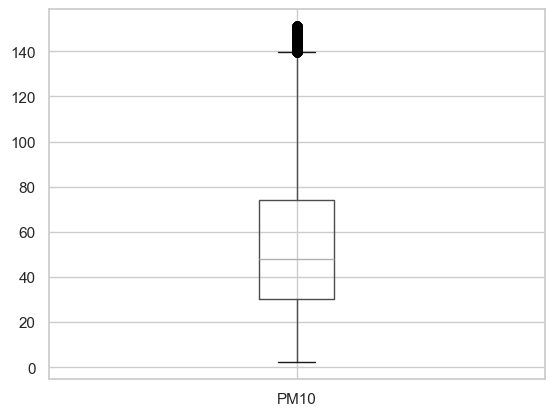

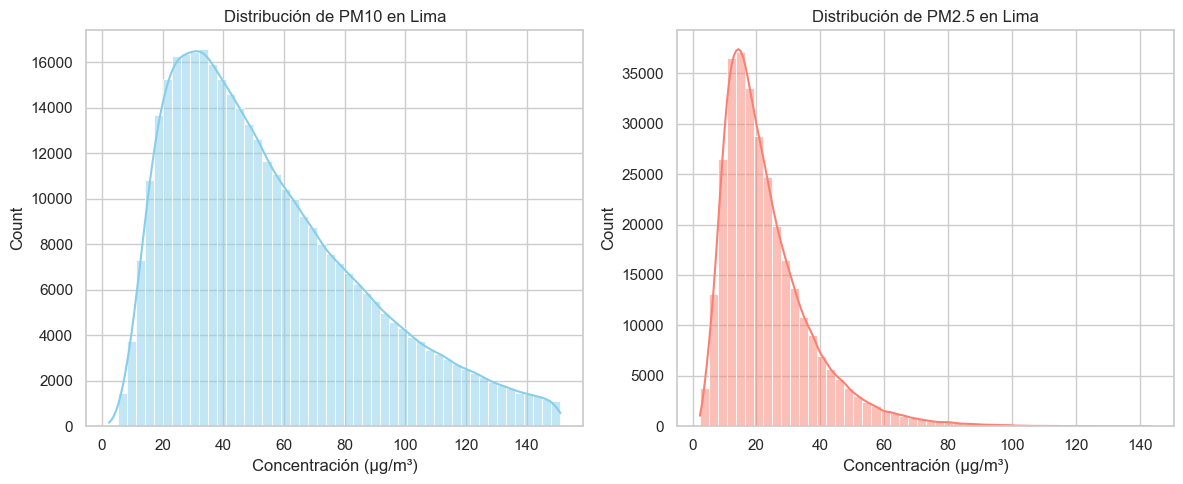

In [24]:
# Histograma
# Configuramos el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Histograma para PM10 (sin outliers para que se vea mejor)
plt.subplot(1, 2, 1)
sns.histplot(df['PM10'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de PM10 en Lima')
plt.xlabel('Concentración (µg/m³)')

# Histograma para PM2.5
plt.subplot(1, 2, 2)
sns.histplot(df['PM2_5'], bins=50, kde=True, color='salmon')
plt.title('Distribución de PM2.5 en Lima')
plt.xlabel('Concentración (µg/m³)')

plt.tight_layout()
plt.show()

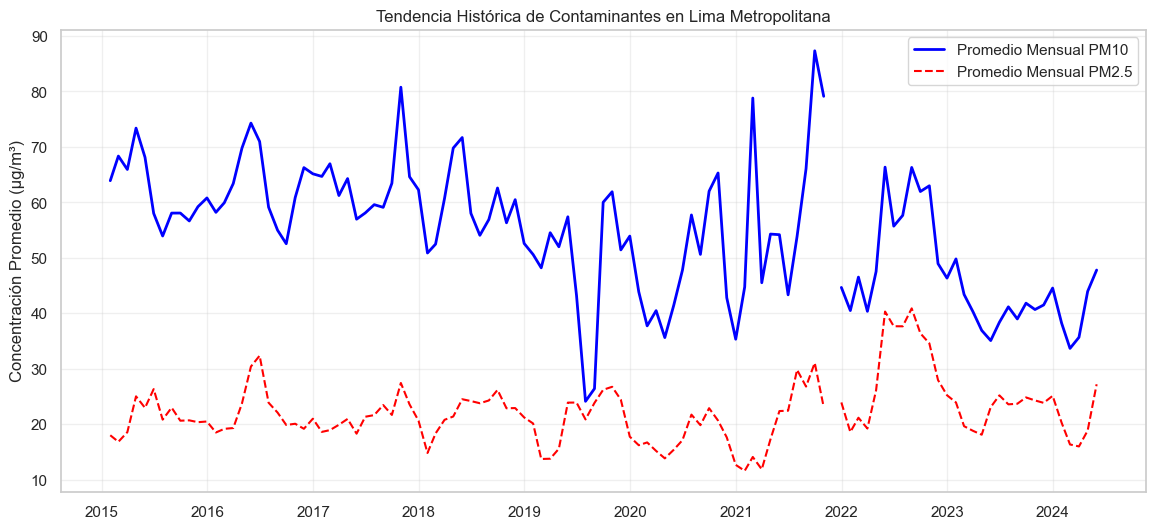

In [25]:
# Series temporales por fecha
df_ts = df.set_index('FECHA')

# Agrupamos por promedio mensual para ver la tendencia de años
pm10_mensual = df_ts['PM10'].resample('ME').mean()
pm25_mensual = df_ts['PM2_5'].resample('ME').mean()
plt.figure(figsize=(14, 6))
plt.plot(pm10_mensual, label='Promedio Mensual PM10', color='blue', linewidth=2)
plt.plot(pm25_mensual, label='Promedio Mensual PM2.5', color='red', linestyle='--')

plt.title('Tendencia Histórica de Contaminantes en Lima Metropolitana')
plt.ylabel('Concentración Promedio (µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

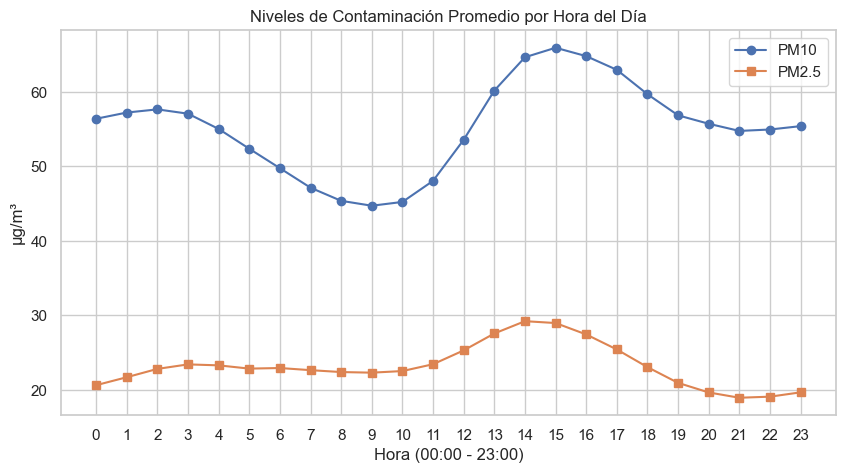

In [26]:
# Series temporales por hora
df_ts['SOLO_HORA'] = pd.to_datetime(df_ts['HORA'], format='%H:%M:%S').dt.hour

# Agrupamos por hora y calculamos el promedio
ciclo_diario = df_ts.groupby('SOLO_HORA')[['PM10', 'PM2_5']].mean()

plt.figure(figsize=(10, 5))
plt.plot(ciclo_diario.index, ciclo_diario['PM10'], marker='o', label='PM10')
plt.plot(ciclo_diario.index, ciclo_diario['PM2_5'], marker='s', label='PM2.5')
plt.xticks(range(0, 24))
plt.title('Niveles de Contaminación Promedio por Hora del Día')
plt.xlabel('Hora (00:00 - 23:00)')
plt.ylabel('µg/m³')
plt.legend()
plt.show()


## 5. Prototipo de Simulación Montecarlo

Explicación técnica
Simulación Estocástica: Es un método que utiliza variables aleatorias para modelar fenómenos inciertos.
Distribución Normal: Asumimos que los niveles de contaminación siguen una campana de Gauss, definida por su Promedio ($\mu$) y su Desviación Estándar ($\sigma$).
Iteraciones: Es el número de veces que repetimos el experimento (ej: 10,000 veces) para obtener un resultado robusto.

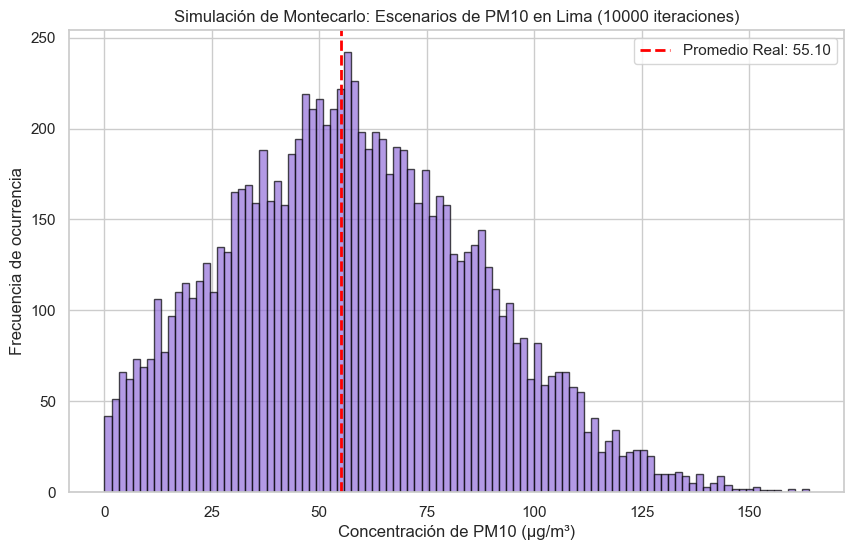

In [27]:
# 1. Parámetros basados en tu análisis previo (ajusta según tus resultados reales)
mu = df['PM10'].mean()      # Promedio real
sigma = df['PM10'].std()    # Desviación estándar real
iteraciones = 10000                      # Número de escenarios a simular

# 2. Generación de escenarios aleatorios
# Creamos una muestra de 10,000 valores basados en la distribución de Lima
simulacion_pm10 = np.random.normal(mu, sigma, iteraciones)

# 3. Limpieza de la simulación (la contaminación no puede ser negativa)
simulacion_pm10 = simulacion_pm10[simulacion_pm10 > 0]

# 4. Visualización de los resultados
plt.figure(figsize=(10, 6))
plt.hist(simulacion_pm10, bins=100, color='mediumpurple', alpha=0.7, edgecolor='black')
plt.axvline(mu, color='red', linestyle='dashed', linewidth=2, label=f'Promedio Real: {mu:.2f}')
plt.title(f'Simulación de Montecarlo: Escenarios de PM10 en Lima ({iteraciones} iteraciones)')
plt.xlabel('Concentración de PM10 (µg/m³)')
plt.ylabel('Frecuencia de ocurrencia')
plt.legend()
plt.show()


In [28]:
# Definimos un límite de alerta (ejemplo: 100 µg/m³)
limite_alerta = 100
excesos = np.sum(simulacion_pm10 > limite_alerta)
probabilidad = (excesos / len(simulacion_pm10)) * 100

print(f"En {iteraciones} escenarios simulados:")
print(f"- El promedio simulado es: {np.mean(simulacion_pm10):.2f} µg/m³")
print(f"- La probabilidad de superar los {limite_alerta} µg/m³ es del {probabilidad:.2f}%")

En 10000 escenarios simulados:
- El promedio simulado es: 58.14 µg/m³
- La probabilidad de superar los 100 µg/m³ es del 8.53%


## 6. Implementación de simulaciones de Monte Carlo - Secuencial vs Paralelo

In [29]:
from concurrent.futures import ProcessPoolExecutor
import numpy as np

def ejecutar_lote_simulacion(args):
    """
    Realiza un lote de simulaciones para reducir el overhead de comunicación.
    """
    media, std, n_puntos, n_iteraciones_lote = args
    resultados_lote = []
    for _ in range(n_iteraciones_lote):
        simulacion = np.random.normal(media, std, n_puntos)
        resultados_lote.append(simulacion.mean())
    return resultados_lote

In [30]:
# --- CONFIGURACIÓN ---
media_h = df['PM10'].mean()
std_h   = df['PM10'].std()

n_puntos      = 1000
n_iteraciones = 10000000
n_nucleos     = multiprocessing.cpu_count()

print(f"--- Iniciando Simulación de Montecarlo ({n_iteraciones} iteraciones) ---")

# --- SECUENCIAL ---
print("\nEjecutando versión secuencial...")
inicio_seq = time.time()
res_secuencial = ejecutar_lote_simulacion((media_h, std_h, n_puntos, n_iteraciones))
tiempo_seq = time.time() - inicio_seq
print(f"Tiempo Secuencial: {tiempo_seq:.4f} segundos")

# --- PARALELO con ThreadPoolExecutor (compatible con Jupyter en Windows) ---
print(f"\nEjecutando versión paralela con {n_nucleos} núcleos...")
inicio_par = time.time()

iteraciones_por_nucleo = n_iteraciones // n_nucleos
tareas = [(media_h, std_h, n_puntos, iteraciones_por_nucleo) for _ in range(n_nucleos)]

with ThreadPoolExecutor(max_workers=n_nucleos) as executor:
    resultados_anidados = list(executor.map(ejecutar_lote_simulacion, tareas))

res_paralelo = [item for sublist in resultados_anidados for item in sublist]
tiempo_par = time.time() - inicio_par
print(f"Tiempo Paralelo: {tiempo_par:.4f} segundos")

# --- MÉTRICAS ---
speedup    = tiempo_seq / tiempo_par
eficiencia = speedup / n_nucleos

print("\n--- RESULTADOS DE RENDIMIENTO ---")
print(f"Speedup alcanzado:      {speedup:.2f}x")
print(f"Eficiencia del sistema: {eficiencia:.2%}")

--- Iniciando Simulación de Montecarlo (10000000 iteraciones) ---

Ejecutando versión secuencial...
Tiempo Secuencial: 244.9506 segundos

Ejecutando versión paralela con 8 núcleos...
Tiempo Paralelo: 452.4561 segundos

--- RESULTADOS DE RENDIMIENTO ---
Speedup alcanzado:      0.54x
Eficiencia del sistema: 6.77%
